# P2 - RNNs

**Authors**:
- Pablo Diaz 
- Daniel Prieto

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Preprocessing of the data

Load the data and preprocess it

In [2]:
df = pd.read_csv("data/nyiso_hourly_load.csv")
df.head()

,Time Stamp,CAPITL,CENTRL,DUNWOD,GENESE,HUD VL,LONGIL,MHK VL,MILLWD,N.Y.C.,NORTH,WEST,total_load
0,2021-01-01 05:00:00+00:00,1229.765829,1652.064229,601.434650,980.770850,1001.962714,2061.066821,841.068829,319.410071,4808.552936,635.814164,1525.174400,15657.085493
1,2021-01-01 06:00:00+00:00,1199.764783,1606.512858,579.089583,934.267075,960.858267,1946.459783,807.607275,307.969050,4631.978808,633.340358,1473.827217,15081.675058
2,2021-01-01 07:00:00+00:00,1172.361075,1578.671450,559.861700,913.383017,936.291717,1855.849567,796.252242,301.264983,4486.644667,617.937925,1435.501408,14654.019750
3,2021-01-01 08:00:00+00:00,1164.461967,1556.862842,548.799792,901.166967,916.932750,1797.270625,794.205750,295.269642,4372.209042,615.713533,1417.398217,14380.291125
4,2021-01-01 09:00:00+00:00,1177.303475,1561.628092,545.171408,898.999517,915.355317,1791.221000,798.552250,295.507442,4336.574433,615.466042,1419.729483,14355.508458


In [3]:
print(df.columns)

Index(['Time Stamp', 'CAPITL', 'CENTRL', 'DUNWOD', 'GENESE', 'HUD VL',
       'LONGIL', 'MHK VL', 'MILLWD', 'N.Y.C.', 'NORTH', 'WEST', 'total_load'],
      dtype='str')


Create a temporal split, since the data is time series data, we cannot do a random split. We will use the following splits: 

- Training set: 2021–2023
- Validation set: 2024
- Test set: 2025

In [4]:
# split the data into training/validation/test sets

# Training Set 2021 to 2023
train_df = df[df["Time Stamp"] < "2024-01-01"]
print(len(train_df))

# Validation Set 2024
val_df = df[(df["Time Stamp"] >= "2024-01-01") & (df["Time Stamp"] < "2025-01-01")]
print(len(val_df))

# Test Set 2025
test_df = df[df["Time Stamp"] >= "2025-01-01"]
print(len(test_df))

# drop the "Time Stamp" column
train_df = train_df.drop(columns=["Time Stamp"])
val_df = val_df.drop(columns=["Time Stamp"])
test_df = test_df.drop(columns=["Time Stamp"])

26107
8784
8765


Now we start the preparation of the data that will be fed to the models. First we are going to standardize the data, using pandas utility functions on dataframes. We start by getting the mean and standard deviation of the training set and then we can apply the standardization to the training, validation and test sets. It is done this way to avoid data leakage, since we will be using just the training set to train the models, it it only fair to use just the training set to compute the mean and standard deviation.

In [5]:
mean = train_df.mean()
std = train_df.std()

print(f"Mean:\n{mean}\n")
print(f"Standard Deviation:\n{std}\n")

Mean:
CAPITL         1327.515791
CENTRL         1736.799880
DUNWOD          646.373512
GENESE         1087.183369
HUD VL         1051.645915
LONGIL         2276.543855
MHK VL          837.988563
MILLWD          322.531092
N.Y.C.         5593.559854
NORTH           646.981059
WEST           1676.361131
total_load    17203.484021
dtype: float64

Standard Deviation:
CAPITL         233.315696
CENTRL         272.144257
DUNWOD         146.049529
GENESE         189.547436
HUD VL         232.391308
LONGIL         634.965917
MHK VL         159.596627
MILLWD          76.722991
N.Y.C.        1148.912783
NORTH           65.901310
WEST           224.922815
total_load    3085.204590
dtype: float64



In [6]:
train_df_scaled = (train_df - mean) / std
val_df_scaled = (val_df - mean) / std
test_df_scaled = (test_df - mean) / std

At this point the data is standardized, but we still need to prepare the data in a way that can be fed to the recurrent models. We need to create sequences of data that will be fed to the models. For this point we tried different sequence lengths with the base RNN model, to find which sequence length worked best at first. We started with a sequence length of 168 (7 days) since we had hypothesized that the weekly patterns would be of interest. However, after some experimentation, we found that shorther sequences worked better, and the best sequence length was 24 hours.

In [7]:
from keras.utils import timeseries_dataset_from_array

# sequences of 168 hours (1 week) to predict total load 3 hours ahead
sequence_length = 24
# sequence_length = 72

batch_size = 32
sample_rate = 1  # hourly data, so one sample per hour
delay = sample_rate * (sequence_length + 3 - 1)  # 3 hours in the future

train_ds = timeseries_dataset_from_array(
    data=train_df_scaled.values,
    targets=train_df_scaled["total_load"][delay:].values,
    sequence_length=sequence_length,
    batch_size=batch_size,
    shuffle=True,
)

val_ds = timeseries_dataset_from_array(
    data=val_df_scaled.values,
    targets=val_df_scaled["total_load"][delay:].values,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

test_ds = timeseries_dataset_from_array(
    data=test_df_scaled.values,
    targets=test_df_scaled["total_load"][delay:].values,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

In [8]:
epochs = 100

### Utils functions

### Plot

In [9]:
import matplotlib.pyplot as plt


def plot_mae(history, std=1.0):
    loss = [v * std for v in history.history["mae"]]
    val_loss = [v * std for v in history.history["val_mae"]]
    epochs = range(1, len(loss) + 1)
    plt.figure()
    plt.plot(epochs, loss, "b-o", label="Training MAE")
    plt.plot(epochs, val_loss, "r--o", label="Validation MAE")
    plt.title("Training and validation MAE")
    plt.ylabel("MAE (MW)")
    plt.xlabel("Epoch")
    plt.legend()
    plt.show()

## Baselines

### Last Value Baseline

A last value baseline is a simple model that just predicts the last value of the sequence as the next value. This is a really simple model but it can be a good baseline to compare the models. 

In [10]:
mean_total = mean["total_load"]
std_total = std["total_load"]


def evaluate_baseline(dataset, get_pred_fn):
    total_abs_error = 0
    samples_counter = 0
    for samples, targets in dataset:
        preds = get_pred_fn(samples) * std_total + mean_total
        tgts = targets * std_total + mean_total
        total_abs_error += np.sum(np.abs(preds - tgts))
        samples_counter += samples.shape[0]
    return total_abs_error / samples_counter


# last observed total_load value (position -1 in window, feature -1 = total_load)
last_value_fn = lambda samples: samples[:, -1, -1]

print(f"Last Value — Validation MAE: {evaluate_baseline(val_ds, last_value_fn):.2f}")
print(f"Last Value — Test MAE:       {evaluate_baseline(test_ds, last_value_fn):.2f}")

Last Value — Validation MAE: 1402.25
Last Value — Test MAE:       1399.68


### Last Day Baseline

A last day baseline is a simple model that just predicts the value of the same hour of the previous day as the next value. This is a really simple model as well, but it could be useful to compare the models since the data might have strong daily patterns.

In [11]:
# Target is 3h after the last element (pos 24), so 24h before target is pos 24+3-24 = 3
daily_fn = lambda samples: samples[:, 3, -1]

print(f"Daily Baseline — Validation MAE: {evaluate_baseline(val_ds, daily_fn):.2f}")
print(f"Daily Baseline — Test MAE:       {evaluate_baseline(test_ds, daily_fn):.2f}")

Daily Baseline — Validation MAE: 1018.34
Daily Baseline — Test MAE:       1117.68


### Neural Baseline (Conv1D + Dense)

In [12]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.Conv1D(64, 5, activation="relu", padding="causal")(inputs)
x = layers.Conv1D(32, 3, activation="relu", padding="causal")(x)
x = layers.Flatten()(x)
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(1)(x)
model_conv = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_conv.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.2, min_lr=1e-5),
]

optimizer = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
model_conv.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

history_conv = model_conv.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

Epoch 1/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0568 - mae: 0.1736 - val_loss: 0.0340 - val_mae: 0.1420 - learning_rate: 0.0010
Epoch 2/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0274 - mae: 0.1261 - val_loss: 0.0353 - val_mae: 0.1400 - learning_rate: 0.0010
Epoch 3/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0221 - mae: 0.1128 - val_loss: 0.0389 - val_mae: 0.1533 - learning_rate: 0.0010
Epoch 4/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0191 - mae: 0.1054 - val_loss: 0.0246 - val_mae: 0.1208 - learning_rate: 0.0010
Epoch 5/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0180 - mae: 0.1017 - val_loss: 0.0279 - val_mae: 0.1260 - learning_rate: 0.0010
Epoch 6/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0171 - mae: 0.0986 - val_loss: 0.0250 - val_mae: 0.1227 - learning_rate: 0.0010
Epoch 7/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0153 - mae: 0.0937 - val_loss: 0.0275 - val_mae: 0.1210 - learning_rate: 0.0010

274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0257 - mae: 0.1165
Test MAE: 359.52
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0165 - mae: 0.0946
Val MAE:  291.78


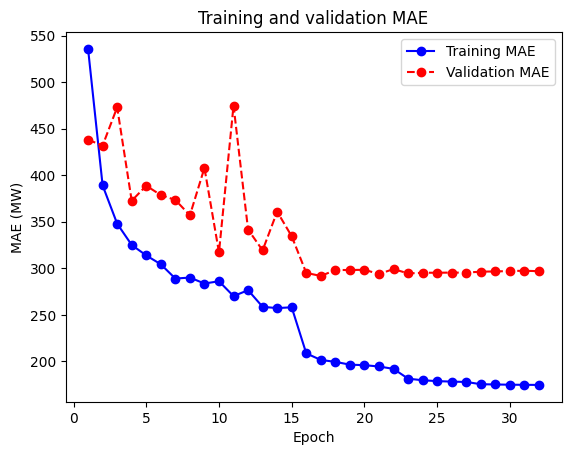

In [13]:
model_conv = keras.models.load_model("models_s24_b32/jena_conv.keras")
print(f"Test MAE: {model_conv.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Val MAE:  {model_conv.evaluate(val_ds)[1] * std_total:.2f}")

plot_mae(history_conv, std=std_total)

## Part 2: Recurrent Models

For each model type we start with a base configuration and then explore:
- **Recurrent dropout** — applying a fixed dropout mask to recurrent activations (Gal & Ghahramani, 2016).
- **Stacked layers** — increasing model depth using `return_sequences=True` on the first layer.

We explore different configurations for all the models, but we will report the best configuration found for each one.

For the SimpleRNN we do not explore the stacked option since it is not a very powerful model and it is not expected to benefit from having more layers. Mainly due to the vanishing gradient problem that SimpleRNNs have, which makes it difficult for the model to learn long-term dependencies.

All models will try to use `AdamW` or `RMSprop` optimizers and `batch_size=64` to keep comparisons fair. The main difference expected betweent the two optimizers is that `AdamW` includes weight decay, which can help with regularization and prevent overfitting, while `RMSprop` is an adaptive learning rate optimizer that can help with convergence. We will see which one works better for each model.

### SimpleRNN

#### Base model

As mentioned before, a lot of configurations were explored for the SimpleRNN, mainly to see what configuration of the preprocessing step (sequence length) worked best, as well as architectural changes (regularization, recurrent dropout). We started testing the models with a sequence length of 168 (7 days) since we had hypothesized that the weekly patterns would be of interest. However, after some experimentation, we found that a sequence of 24 hours worked better. This might be because of the vanishing gradient problem that SimpleRNNs have, which makes it difficult for the model to learn long-term dependencies.

For the archictecture, we use 128 units, in earlier experiments we found that the model benefited from having more units. A Dense(32) hidden layer is added between the recurrent output and the final output layer.

In [14]:
from typing import cast

import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.SimpleRNN(128)(inputs)
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_rnn_128.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=5, min_lr=1e-5),
]

optimizer = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)

model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

history_simple_rnn = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

Epoch 1/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0556 - mae: 0.1655 - val_loss: 0.0360 - val_mae: 0.1488 - learning_rate: 0.0010
Epoch 2/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0250 - mae: 0.1213 - val_loss: 0.0314 - val_mae: 0.1335 - learning_rate: 0.0010
Epoch 3/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0222 - mae: 0.1140 - val_loss: 0.0398 - val_mae: 0.1600 - learning_rate: 0.0010
Epoch 4/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0200 - mae: 0.1077 - val_loss: 0.0235 - val_mae: 0.1188 - learning_rate: 0.0010
Epoch 5/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0181 - mae: 0.1026 - val_loss: 0.0253 - val_mae: 0.1207 - learning_rate: 0.0010
Epoch 6/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0175 - mae: 0.1006 - val_loss: 0.0215 - val_mae: 0.1103 - learning_rate: 0.0010
Epoch 7/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0173 - mae: 0.0998 - val_loss: 0.0236 - val_mae: 0.1194 - learning_rate: 0.0010

274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0288 - mae: 0.1218
Test MAE: 375.67
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0160 - mae: 0.0922
Val MAE:  284.44


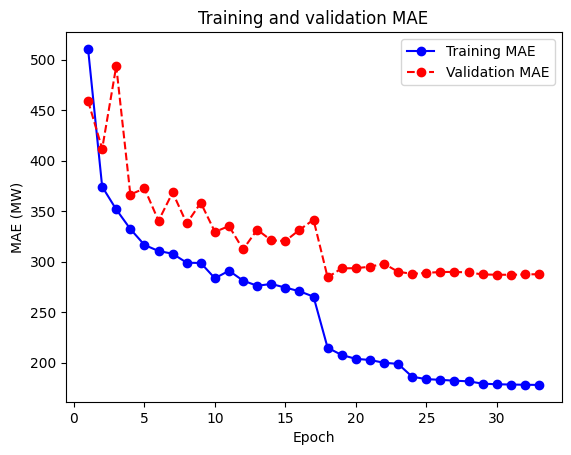

In [15]:
model = keras.models.load_model("models_s24_b32/jena_rnn_128.keras")
model = cast(keras.Model, model)

print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Val MAE:  {model.evaluate(val_ds)[1] * std_total:.2f}")

plot_mae(history_simple_rnn, std=std_total)

#### SimpleRNN with recurrent dropout

We can see on the graph above that the base model is kind of overfitting, the difference between the training and validation errors is quite susbtantial, as well as the the loss which is minimal on the training but not on the validation set. We are going to try to apply recurrent dropout and a dropout layer. To compensate for the regularization we are going to increase the number of units to 256, since we have seen that the model can benefit from more capacity.

In [16]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.SimpleRNN(256, recurrent_dropout=0.1)(inputs)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_rnn_dropout.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=5, min_lr=1e-5, verbose=1),
]

optimizer = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)

model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
history_rnn_dropout = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

Epoch 1/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0976 - mae: 0.2371 - val_loss: 0.0448 - val_mae: 0.1625 - learning_rate: 0.0010
Epoch 2/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0574 - mae: 0.1852 - val_loss: 0.0336 - val_mae: 0.1430 - learning_rate: 0.0010
Epoch 3/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0470 - mae: 0.1675 - val_loss: 0.0373 - val_mae: 0.1542 - learning_rate: 0.0010
Epoch 4/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0455 - mae: 0.1640 - val_loss: 0.0349 - val_mae: 0.1452 - learning_rate: 0.0010
Epoch 5/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0434 - mae: 0.1600 - val_loss: 0.0319 - val_mae: 0.1388 - learning_rate: 0.0010
Epoch 6/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0430 - mae: 0.1598 - val_loss: 0.0452 - val_mae: 0.1594 - learning_rate: 0.0010
Epoch 7/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0456 - mae: 0.1632 - val_loss: 0.0368 - val_mae: 0.1488 - learning_rate: 0.0010

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0356 - mae: 0.1355
Test MAE: 417.92
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0190 - mae: 0.1005
Val MAE:  310.08


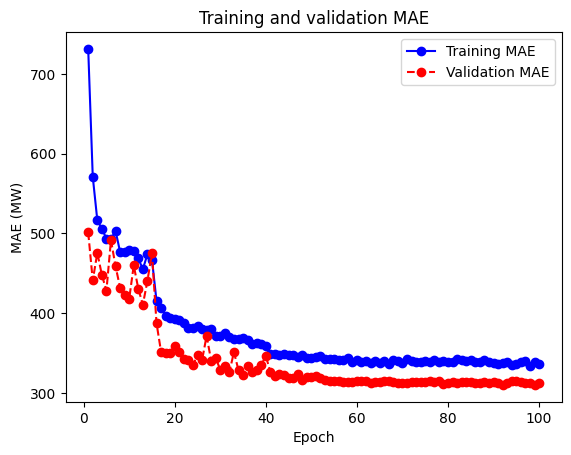

In [17]:
model = keras.models.load_model("models_s24_b32/jena_rnn_dropout.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Val MAE:  {model.evaluate(val_ds)[1] * std_total:.2f}")

plot_mae(history_rnn_dropout, std=std_total)

The training curves show something interesting, the validation MAE is below the training MAE always. This does not mean that there is data leakage or something is wrong, but a consequence of the regularization caused by the dropout and recurrent dropout. 

In the end, the model is performs quite similar to the base model. The test MAE is very similar to the base model. This could mean that the overfitting saw in the base model was not really a problem, and that the regularization did not really help the model to generalize better.

Therefore, in this case, the regularization did not really help the model to generalize better, and the base model is already good enough for this problem.

### LSTM

#### Base model

In [18]:
import keras
from keras import layers
from keras import regularizers

inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.LSTM(128, kernel_regularizer=regularizers.l2(1e-4))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_lstm.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=5, min_lr=0.00001, verbose=1
    ),
]

custom_optimizer = keras.optimizers.RMSprop(learning_rate=0.001, clipvalue=1.0)

model.compile(optimizer=custom_optimizer, loss="mse", metrics=["mae"])
history_lstm = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)
# model = keras.models.load_model("models_s24_b32/jena_lstm.keras")
# print(f"Test MAE: {model.evaluate(test_ds_72)[1] * std_total:.2f}")
# print(f'Validation MAE: {model.evaluate(val_ds_72)[1] * std_total:.2f}')

Epoch 1/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0648 - mae: 0.1855 - val_loss: 0.0931 - val_mae: 0.2366 - learning_rate: 0.0010
Epoch 2/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0283 - mae: 0.1238 - val_loss: 0.0368 - val_mae: 0.1417 - learning_rate: 0.0010
Epoch 3/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0232 - mae: 0.1107 - val_loss: 0.0394 - val_mae: 0.1456 - learning_rate: 0.0010
Epoch 4/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0206 - mae: 0.1041 - val_loss: 0.0285 - val_mae: 0.1220 - learning_rate: 0.0010
Epoch 5/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0189 - mae: 0.0992 - val_loss: 0.0382 - val_mae: 0.1444 - learning_rate: 0.0010
Epoch 6/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0178 - mae: 0.0962 - val_loss: 0.0274 - val_mae: 0.1218 - learning_rate: 0.0010
Epoch 7/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0168 - mae: 0.0933 - val_loss: 0.0298 - val_mae: 0.1268 - learning_rate: 0.0010

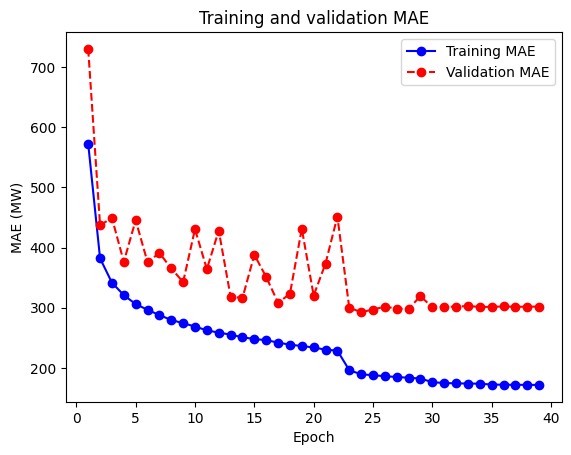

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0325 - mae: 0.1292
Test MAE: 398.57
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0185 - mae: 0.0949
Validation MAE: 292.70


In [19]:
plot_mae(history_lstm, std=std_total)
model = keras.models.load_model("models_s24_b32/jena_lstm.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Validation MAE: {model.evaluate(val_ds)[1] * std_total:.2f}")

#### LSTM with recurrent dropout

We apply the same regularization strategy as with SimpleRNN: `recurrent_dropout=0.25` on the LSTM and `Dropout(0.5)` on its output, with 32 units and 20 training epochs.

In [ ]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.LSTM(128, recurrent_dropout=0.1)(inputs)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_lstm_dropout.keras",
        save_best_only=True,
        monitor="val_loss",
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=5, min_lr=0.00001, verbose=1
    ),
]
epochs = 100
optimizer = keras.optimizers.RMSprop(learning_rate=0.001, clipvalue=1.0)
model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
history_lstm_dropout = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

Epoch 1/100
814/816 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1564 - mae: 0.2901
Epoch 1: val_loss improved from None to 0.10717, saving model to jena_lstm_dropout.keras

Epoch 1: finished saving model to jena_lstm_dropout.keras
816/816 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0855 - mae: 0.2198 - val_loss: 0.1072 - val_mae: 0.2648 - learning_rate: 0.0010
Epoch 2/100
814/816 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0434 - mae: 0.1629
Epoch 2: val_loss improved from 0.10717 to 0.03198, saving model to jena_lstm_dropout.keras

Epoch 2: finished saving model to jena_lstm_dropout.keras
816/816 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 0.0407 - mae: 0.1574 - val_loss: 0.0320 - val_mae: 0.1371 - learning_rate: 0.0010
Epoch 3/100
813/816 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0337 - mae: 0.1425
Epoch 3: val_loss did not improve from 0.03198
816/816 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 0.0330 - mae: 0.1408 - val_loss: 0.0428 - val_mae: 0.1575 - learning_rate: 0.0010
Epoch 

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0301 - mae: 0.1269
Test MAE: 391.36
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0171 - mae: 0.0959
Validation MAE: 295.81


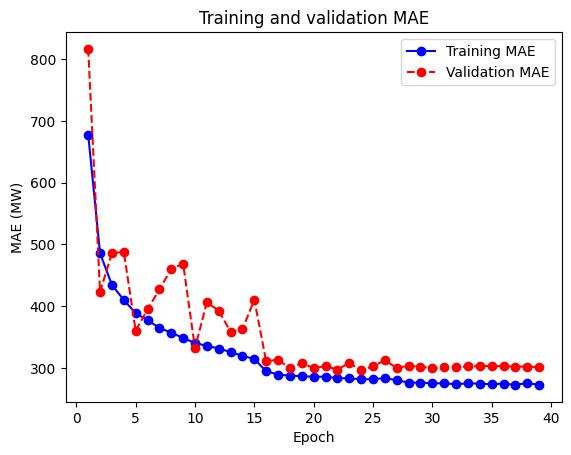

In [22]:
model = keras.models.load_model("models_s24_b32/jena_lstm_dropout.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Validation MAE: {model.evaluate(val_ds)[1] * std_total:.2f}")

plot_mae(history_lstm_dropout, std=std_total)

#### Stacked LSTM

To increase model capacity we stack two LSTM layers. The first must use `return_sequences=True` to pass the full output sequence to the second. We use stronger dropout (`recurrent_dropout=0.5`) to compensate for the additional capacity, and train for 30 epochs.

In [23]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.LSTM(64, recurrent_dropout=0.1, return_sequences=True)(inputs)
x = layers.LSTM(64, recurrent_dropout=0.1)(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_lstm_stacked.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=5, min_lr=0.00001, verbose=1
    ),
]

optimizer = keras.optimizers.RMSprop(learning_rate=0.001, clipvalue=1.0)
model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
history_lstm_stacked = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

Epoch 1/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.1151 - mae: 0.2575 - val_loss: 0.0868 - val_mae: 0.2255 - learning_rate: 0.0010
Epoch 2/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0524 - mae: 0.1776 - val_loss: 0.0515 - val_mae: 0.1732 - learning_rate: 0.0010
Epoch 3/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0386 - mae: 0.1519 - val_loss: 0.0395 - val_mae: 0.1516 - learning_rate: 0.0010
Epoch 4/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0325 - mae: 0.1388 - val_loss: 0.0278 - val_mae: 0.1273 - learning_rate: 0.0010
Epoch 5/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0294 - mae: 0.1318 - val_loss: 0.0303 - val_mae: 0.1330 - learning_rate: 0.0010
Epoch 6/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0268 - mae: 0.1260 - val_loss: 0.0282 - val_mae: 0.1287 - learning_rate: 0.0010
Epoch 7/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0249 - mae: 0.1209 - val_loss: 0.0242 - val_mae: 0.1218 - learnin

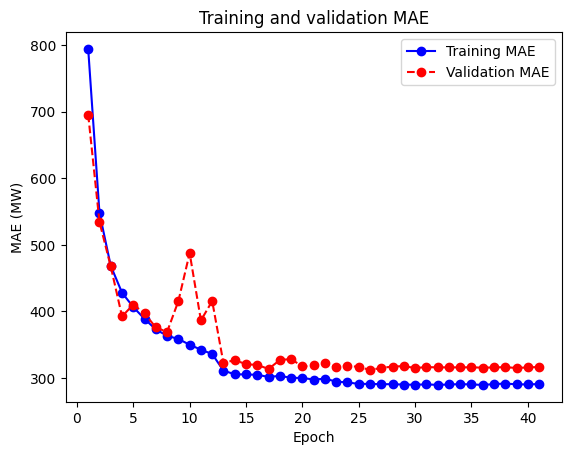

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0352 - mae: 0.1427
Test MAE: 440.29
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0188 - mae: 0.1011
Validation MAE: 312.01


In [24]:
plot_mae(history_lstm_stacked, std=std_total)

model = keras.models.load_model("models_s24_b32/jena_lstm_stacked.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Validation MAE: {model.evaluate(val_ds)[1] * std_total:.2f}")

### GRU

#### Base model

Learning rate mas agresivo para evitar eebote en los minimos globales

Prueba: La capa GRU se encarga de extraer características temporales complejas. Al pasar esas características por una capa Dense intermedia (generalmente con activación ReLU), para una etapa extra de procesamiento no lineal para interpretar esos patrones antes de colapsarlos en un solo número con un dropout para evitatr overfitting -> Se intentó darle más profundidad al modelo y empeoró el rendimiento, demuestra un nivel de análisis, lo que implica que el modelo GRU de 128 ya tenía la capacidad perfecta para este problema y no necesitaba más capas.

Batch size reducido de 64 a 32 para optimizar la búsqueda de un mínimo óptimo y reducir la probabilidad de que el modelo se estanque en mínimos locales

Añadida regularización l2 para reducir overfitting 

In [25]:
import keras
from keras import layers
from keras import regularizers

inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.GRU(128, kernel_regularizer=regularizers.l2(1e-4))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_gru.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=5, min_lr=0.00001
    ),
]

custom_optimizer = keras.optimizers.RMSprop(learning_rate=0.001, clipvalue=1.0)

model.compile(optimizer=custom_optimizer, loss="mse", metrics=["mae"])
history_gru = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

Epoch 1/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0696 - mae: 0.1912 - val_loss: 0.0647 - val_mae: 0.1903 - learning_rate: 0.0010
Epoch 2/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0290 - mae: 0.1260 - val_loss: 0.0828 - val_mae: 0.2131 - learning_rate: 0.0010
Epoch 3/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0239 - mae: 0.1137 - val_loss: 0.0412 - val_mae: 0.1539 - learning_rate: 0.0010
Epoch 4/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0217 - mae: 0.1084 - val_loss: 0.0244 - val_mae: 0.1148 - learning_rate: 0.0010
Epoch 5/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0200 - mae: 0.1033 - val_loss: 0.0407 - val_mae: 0.1596 - learning_rate: 0.0010
Epoch 6/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0189 - mae: 0.1004 - val_loss: 0.0554 - val_mae: 0.1702 - learning_rate: 0.0010
Epoch 7/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0180 - mae: 0.0977 - val_loss: 0.0488 - val_mae: 0.1636 - learning_rate: 0.0010

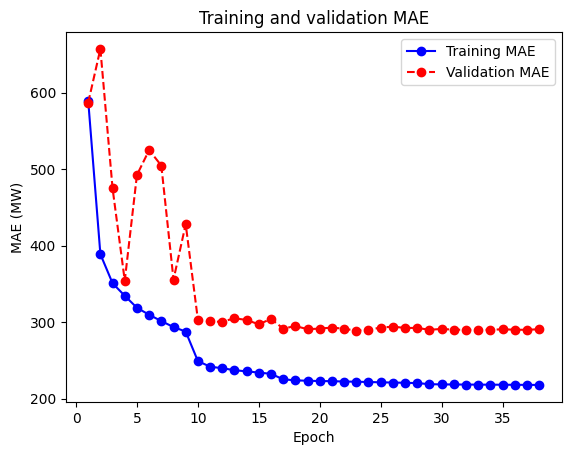

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0281 - mae: 0.1179
Test MAE: 363.90
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0174 - mae: 0.0936
Validation MAE: 288.85


In [26]:
plot_mae(history_gru, std=std_total)

model = keras.models.load_model("models_s24_b32/jena_gru.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Validation MAE: {model.evaluate(val_ds)[1] * std_total:.2f}")

#### GRU with recurrent dropout

Same regularization as LSTM: `recurrent_dropout=0.25`, `Dropout(0.5)`, 32 units, 20 epochs. GRU has fewer parameters than LSTM so it trains faster.

In [27]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.GRU(128, recurrent_dropout=0.1)(inputs)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_gru_dropout.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=5, min_lr=0.00001, verbose=1
    ),
]

optimizer = keras.optimizers.RMSprop(learning_rate=0.001, clipvalue=1.0)

model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
history_gru_dropout = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

Epoch 1/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0879 - mae: 0.2224 - val_loss: 0.0622 - val_mae: 0.1964 - learning_rate: 0.0010
Epoch 2/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0408 - mae: 0.1573 - val_loss: 0.0723 - val_mae: 0.2071 - learning_rate: 0.0010
Epoch 3/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0340 - mae: 0.1424 - val_loss: 0.0455 - val_mae: 0.1631 - learning_rate: 0.0010
Epoch 4/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0298 - mae: 0.1336 - val_loss: 0.0446 - val_mae: 0.1572 - learning_rate: 0.0010
Epoch 5/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0281 - mae: 0.1292 - val_loss: 0.0291 - val_mae: 0.1309 - learning_rate: 0.0010
Epoch 6/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0267 - mae: 0.1258 - val_loss: 0.0374 - val_mae: 0.1435 - learning_rate: 0.0010
Epoch 7/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0251 - mae: 0.1224 - val_loss: 0.0249 - val_mae: 0.1185 - learnin

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0296 - mae: 0.1254
Test MAE: 386.86
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0173 - mae: 0.0968
Validation MAE: 298.76


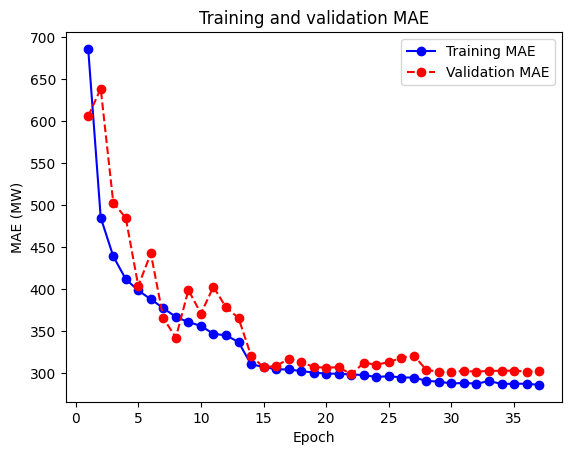

In [28]:
model = keras.models.load_model("models_s24_b32/jena_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Validation MAE: {model.evaluate(val_ds)[1] * std_total:.2f}")

plot_mae(history_gru_dropout, std=std_total)

#### Stacked GRU

Two stacked GRU layers with strong dropout regularization (`recurrent_dropout=0.5`) and 30 training epochs, following the same pattern as stacked LSTM.

In [29]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.GRU(64, recurrent_dropout=0.1, return_sequences=True)(inputs)
x = layers.GRU(64, recurrent_dropout=0.1)(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_gru_stacked.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=5, min_lr=0.00001, verbose=1
    ),
]

optimizer = keras.optimizers.RMSprop(learning_rate=0.001, clipvalue=1.0)
model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
history_gru_stacked = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

Epoch 1/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0904 - mae: 0.2267 - val_loss: 0.0675 - val_mae: 0.2078 - learning_rate: 0.0010
Epoch 2/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0444 - mae: 0.1646 - val_loss: 0.0752 - val_mae: 0.2120 - learning_rate: 0.0010
Epoch 3/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0359 - mae: 0.1472 - val_loss: 0.0582 - val_mae: 0.1846 - learning_rate: 0.0010
Epoch 4/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0319 - mae: 0.1373 - val_loss: 0.0272 - val_mae: 0.1264 - learning_rate: 0.0010
Epoch 5/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0291 - mae: 0.1318 - val_loss: 0.0324 - val_mae: 0.1429 - learning_rate: 0.0010
Epoch 6/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0276 - mae: 0.1279 - val_loss: 0.0377 - val_mae: 0.1458 - learning_rate: 0.0010
Epoch 7/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0257 - mae: 0.1238 - val_loss: 0.0242 - val_mae: 0.1194 - learnin

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0330 - mae: 0.1336
Test MAE: 412.07
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0179 - mae: 0.0992
Validation MAE: 306.08


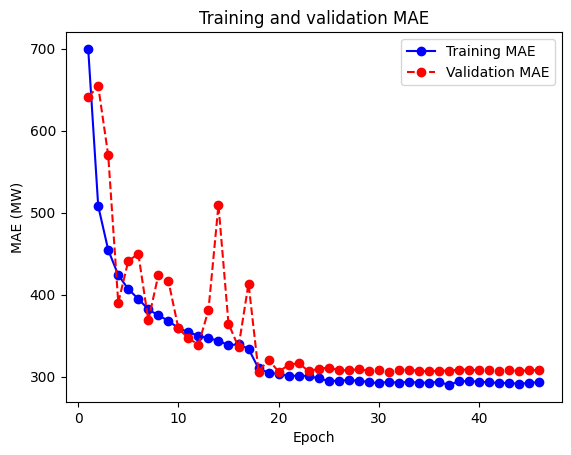

In [30]:
model = keras.models.load_model("models_s24_b32/jena_gru_stacked.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Validation MAE: {model.evaluate(val_ds)[1] * std_total:.2f}")


plot_mae(history_gru_stacked, std=std_total)

## Analysis and Comparison

We collect all test MAEs (denormalized, in MW) and display them in a single table and bar chart.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras

print("Model comparison:")


def get_maes(model_path):
    m = keras.models.load_model(model_path)
    return (
        m.evaluate(test_ds, verbose=0)[1] * std_total,
        m.evaluate(val_ds, verbose=0)[1] * std_total,
    )


model_names = [
    "Last Value Baseline",
    "Daily Baseline",
    "Conv1D Neural Baseline",
    "SimpleRNN (128 units)",
    "SimpleRNN + Dropout (256 units)",
    "LSTM (128 units)",
    "LSTM + Dropout (128 units)",
    "LSTM Stacked (64×2)",
    "GRU (128 units)",
    "GRU + Dropout (128 units)",
    "GRU Stacked (64×2)",
]

maes = [
    (
        evaluate_baseline(test_ds, last_value_fn),
        evaluate_baseline(val_ds, last_value_fn),
    ),
    (evaluate_baseline(test_ds, daily_fn), evaluate_baseline(val_ds, daily_fn)),
    get_maes("models_s24_b32/jena_conv.keras"),
    get_maes("models_s24_b32/jena_rnn_128.keras"),
    get_maes("models_s24_b32/jena_rnn_dropout.keras"),
    get_maes("models_s24_b32/jena_lstm.keras"),
    get_maes("models_s24_b32/jena_lstm_dropout.keras"),
    get_maes("models_s24_b32/jena_lstm_stacked.keras"),
    get_maes("models_s24_b32/jena_gru.keras"),
    get_maes("models_s24_b32/jena_gru_dropout.keras"),
    get_maes("models_s24_b32/jena_gru_stacked.keras"),
]

results_df = pd.DataFrame(
    {
        "Model": model_names,
        "Test MAE (MW)": [mae[0] for mae in maes],
        "Validation MAE (MW)": [mae[1] for mae in maes],
    }
)

results_df["Test MAE (MW)"] = results_df["Test MAE (MW)"].round(2)
results_df["Validation MAE (MW)"] = results_df["Validation MAE (MW)"].round(2)
print(results_df.to_string(index=False))

Model comparison:
                          Model  Test MAE (MW)  Validation MAE (MW)
            Last Value Baseline        1399.68              1402.25
                 Daily Baseline        1117.68              1018.34
         Conv1D Neural Baseline         359.52               291.78
          SimpleRNN (128 units)         375.67               284.44
SimpleRNN + Dropout (256 units)         417.92               310.08
               LSTM (128 units)         398.57               292.70
     LSTM + Dropout (128 units)         391.36               295.81
            LSTM Stacked (64×2)         440.29               312.01
                GRU (128 units)         363.90               288.85
      GRU + Dropout (128 units)         386.86               298.76
             GRU Stacked (64×2)         412.07               306.08


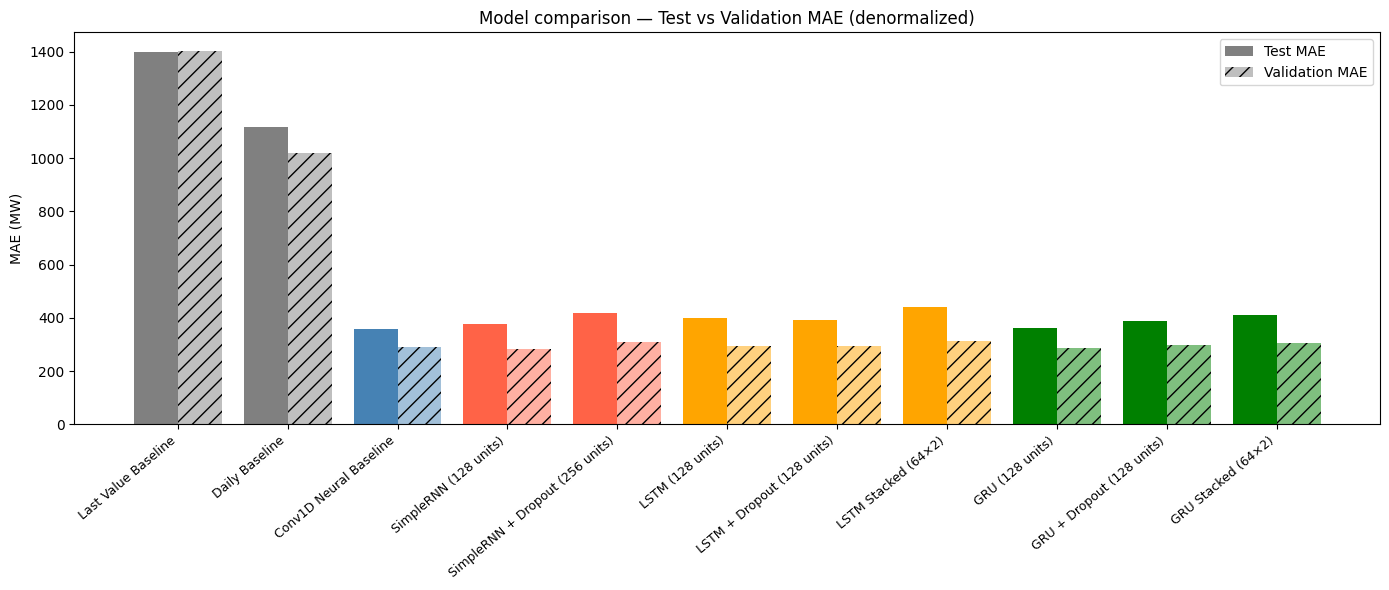

In [34]:
# Bar chart
colors = [
    "gray",
    "gray",
    "steelblue",
    "tomato",
    "tomato",
    "orange",
    "orange",
    "orange",
    "green",
    "green",
    "green",
]
x = np.arange(len(model_names))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 6))

bars_test = ax.bar(
    x - width / 2,
    [mae[0] for mae in maes],
    width,
    label="Test MAE",
    color=colors,
    alpha=1.0,
)
bars_val = ax.bar(
    x + width / 2,
    [mae[1] for mae in maes],
    width,
    label="Validation MAE",
    color=colors,
    alpha=0.5,
    hatch="//",
)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("MAE (MW)")
ax.set_title("Model comparison — Test vs Validation MAE (denormalized)")
ax.legend()
plt.tight_layout()
plt.show()